<a href="https://colab.research.google.com/github/Juan-Vega18/INTRODUC.-CIENCIA-DE-DATOS/blob/main/clase_5_analisis_de_clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ANALISIS DE CLIENTES


|variable|Tipo de Variable|Descripción|
|---|---|---|
|CustomerID|int64 (numérica entera)|El ID (identificador) del cliente|
|Age|int64 (numérica entera)|Edad del Cliente|
|Education|object (categórica) |Nivel educativo|
|Income|int64 (numérica entera)|Ingreso económico|
|Occupation|object (categórica)|Ocupación de la persona|
|Gender|object (categórica)|Género de la persona|
|Marital Status|object (categórica)|Estado Marital de la persona|
|Settlement Size|object (categórica)|En que tipo de ciudad (tamaño) vive|


In [ ]:
#Cargamos las librerias
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns


#Montamos a drive
drive.mount('/mnt/drive')
os.getcwd()
#os.listdir() Listamos los directorios
os.chdir('/mnt/drive/MyDrive/ciencia_de_datos')
os.listdir()

Drive already mounted at /mnt/drive; to attempt to forcibly remount, call drive.mount("/mnt/drive", force_remount=True).


['netflix_data.csv',
 'democracy_data.csv',
 'democracy_data.gsheet',
 'output_file.csv',
 'regicor.csv',
 'customers_1.csv']

In [ ]:
df_hr = pd.read_csv('customers_1.csv') #Creamos el dataframe con el csv
df_hr.info() #Obtenemos información de las variables

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       2000 non-null   int64 
 1   Age              2000 non-null   int64 
 2   Education        2000 non-null   object
 3   Income           2000 non-null   int64 
 4   Occupation       2000 non-null   object
 5   Gender           2000 non-null   object
 6   Marital Status   2000 non-null   object
 7   Settlement Size  2000 non-null   object
dtypes: int64(3), object(5)
memory usage: 125.1+ KB


In [ ]:
#Hallar la media

media_edad = df_hr['Age'].mean() #Calculamos la media de la edad
media_salario = df_hr['Income'].mean() #Calculamos la media del salario
print(f'La edad promedio de la empresa es: {media_edad:.1f} años') #El f significa float y el 1 es, 1 solo decimal
print(f'El Salario promedio (Media es ${media_salario:,.2f} USD ') #Aqui pasa lo mismo pero queremos 2 decimales despues de la coma.

La edad promedio de la empresa es: 35.9 años
El Salario promedio (Media es $120,954.42 USD 


La mediana de Salario de la empresa es: $115548.500000 dolares


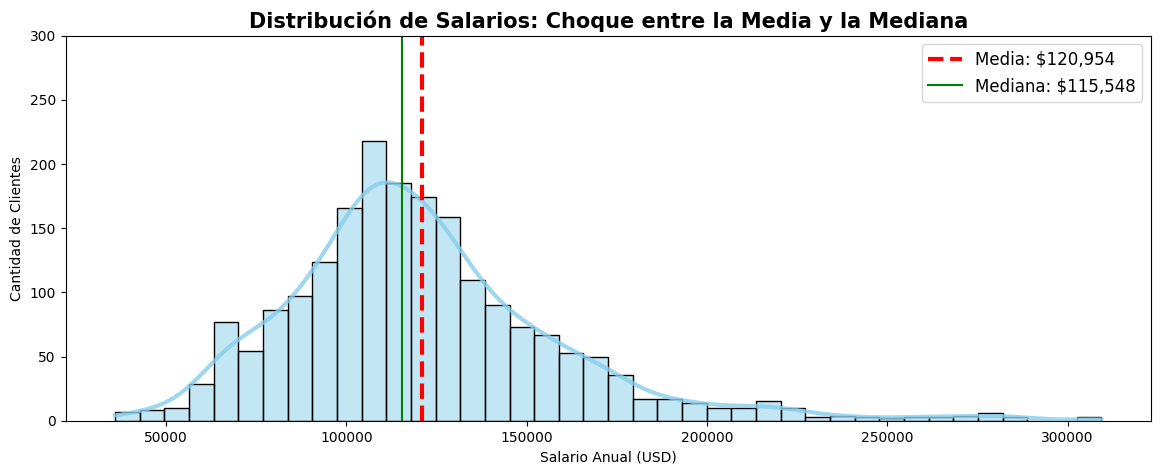

In [ ]:
#Hallar la mediana
mediana_salario = df_hr['Income'].median() #Calculamos la mediana del salario
print(f'La mediana de Salario de la empresa es: ${mediana_salario:1f} dolares')

plt.figure(figsize=(14,5)) #Tamaño de la figura
sns.histplot(df_hr['Income'], bins=40, color='skyblue', kde=True,
             line_kws={'linewidth': 3, 'color': 'navy', 'alpha': 0.8}) #Destacamos la envolvemnte en azul oscuro #Creamos el histograma de salarios

plt.axvline(media_salario, color='red', linestyle = 'dashed', linewidth = 3, label=f'Media: ${media_salario:,.0f}') #Añadimos las lineas verticales de media y mediana
plt.axvline(mediana_salario, color='green', linestyle = 'solid', label=f'Mediana: ${mediana_salario:,.0f}')

plt.title('Distribución de Salarios: Choque entre la Media y la Mediana', fontsize= 15, fontweight ='bold') #Asignamos titulo del plot
plt.xlabel('Salario Anual (USD)') #Titulo eje x
plt.ylabel('Cantidad de Clientes') #Titulo eje y
plt.ylim(0,300) #Definimos los limites
plt.legend(fontsize=12) #Definimos la fuente de la legenda
plt.show()

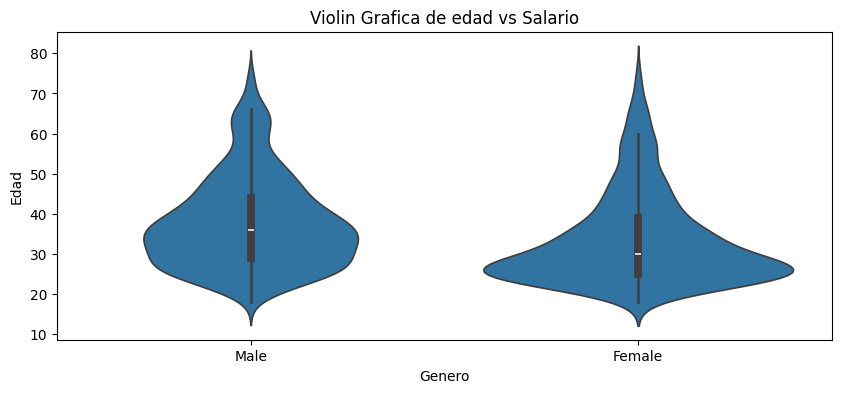

In [ ]:
# Violin plot
plt.figure(figsize=(10, 4)) #Tamaño de la figura
sns.violinplot(y='Age', x='Gender', data=df_hr) #Creo el grafico violin y defino las variables y e x.
plt.title('Violin Grafica de edad vs Salario') #Defino el titulo del plot
plt.xlabel('Genero') #Defino el titulo del eje x
plt.ylabel('Edad') #Defino del titulo del eje y
plt.show()

115548.5


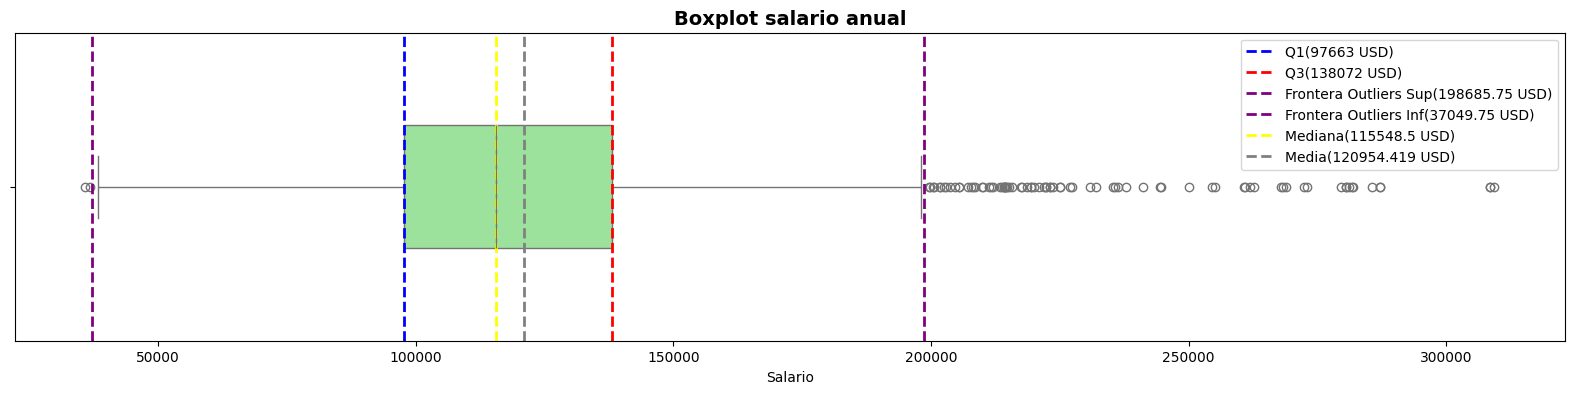

In [ ]:
plt.figure(figsize=(20,4)) #Defino tamaño de la figura boxplot
sns.boxplot(x=df_hr['Income'], color='lightgreen', width=0.4) #creo el boxplot y pongo como variable income
Q1 = df_hr['Income'].quantile(0.25) #Calculo el Cuartil 1
mediana = df_hr['Income'].median() #Calculo la mediana
media = df_hr['Income'].mean() #Calculo la media
Q3 = df_hr['Income'].quantile(0.75) #Calculo el Cuartil 3
IQR = Q3 - Q1 #Calculo el rango intercuartilico
lim_sup = Q3 + 1.5*IQR #Calculo el limite superior
lim_inf = Q1 - 1.5*IQR #Calculo del limite inferior
print(mediana)

#trazos verticales
#Creo todos los trazos verticales para los cuartiles, fronteras, mediana y media.
plt.axvline(Q1, color = 'blue', linestyle ='--', linewidth ='2', label=f'Q1({Q1:.0f} USD)')
plt.axvline(Q3, color = 'red', linestyle ='--', linewidth ='2', label=f'Q3({Q3:.0f} USD)')
plt.axvline(lim_sup, color = 'purple', linestyle ='--', linewidth ='2', label=f'Frontera Outliers Sup({lim_sup} USD)')
plt.axvline(lim_inf, color = 'purple', linestyle ='--', linewidth ='2', label=f'Frontera Outliers Inf({lim_inf} USD)')
plt.axvline(mediana, color = 'yellow', linestyle ='--', linewidth ='2', label=f'Mediana({mediana} USD)')
plt.axvline(media, color = 'gray', linestyle ='--', linewidth ='2', label=f'Media({media} USD)')

plt.title('Boxplot salario anual', fontsize=14, fontweight='bold') #Defino titulo del boxplot
plt.xlabel('Salario') #Defino el nombre del eje x
plt.legend()
plt.show()